# Steel: cooling curve in, microstructure out

*A guided what-if over the validated steel-production chain.*

You austenitize a steel, cool it, and ask **what material do I get** — soft and
machinable, or file-hard? This notebook walks that question end to end and lets
you **turn the knobs**: carbon, alloy grade, quench medium, section size, temper,
and the austenitizing soak.

Every number here is produced by a function that is **validated in isolation**
(`steel/…`, each with its own test triad). The notebook is a *thin
skin*: each compute cell calls the headless `sweep` / `properties` / `fe_c` /
`grain` harness directly, then `ipywidgets` sliders re-run that same harness live.
Per [ADR 0002](../../docs/decisions/0002-visualization-and-ux.md) the figures
*consume* validated arrays — they are reach, not evidence.

The arc:

1. **The endpoint** — where carbon sends a *slowly-cooled* steel (`fe_c`).
2. **The mechanism** — the TTT C-curve, and why *how fast* you cool decides the
   microstructure (`sweep` → the four-curves anchor).
3. **Hardenability** — the composition axis: why an alloy steel hardens deeper.
4. **Tempering** — trading hardness back for toughness (Hollomon–Jaffe).
5. **Grain size** — the austenitizing soak, and the one lever that makes a steel
   *stronger **and** tougher at once* (`grain`: yield + DBTT).
6. **Austempering** — stop *inside* the diagram: the isothermal bainite hold
   (`austemper`, anchored per steel to the US Steel 1951 atlas).

## Start here — the 30-second mental model

New to heat treatment? Read this once and the sections below will click.

**Steel is iron with a little carbon** (here, ~0.1–1 %). Heat it red-hot (~850 °C)
and it becomes **austenite** — a soft phase that *dissolves* the carbon. Everything
interesting happens in the seconds *after* you start cooling: where that carbon
goes decides whether you get a soft, machinable part or a glass-hard one.

You have **a few knobs**, and the notebook gives you one section per knob:

| Knob | What it changes | Section |
|---|---|---|
| **How much carbon** | the *potential* hardness (more C → harder, up to a point) | §1, §3 |
| **What alloy** (Mn, Cr, Mo…) | how *deep* the hardness reaches — "hardenability" | §3 |
| **How fast you cool** | *which* microstructure actually forms | §2 |
| **Temper** (reheat afterward) | trade hardness back for toughness | §4 |
| **Austenitizing soak** (how hot/long before cooling) | the **grain size** → yield + toughness | §5 |

**Mini-glossary** — the words the figures use:

- **Austenite (γ)** — the hot parent phase; soft, holds the carbon in solution.
- **Ferrite (α)** — nearly pure iron; soft and tough.
- **Cementite (Fe₃C)** — an iron carbide; very hard, brittle.
- **Pearlite** — fine layers of ferrite + cementite from *slow* cooling; moderate.
- **Bainite** — an intermediate product of medium cooling.
- **Martensite** — from a *fast* quench: carbon trapped, very hard and brittle.
- **Tempering** — gently reheating quenched steel to win back toughness.
- **Grain size** — how big the crystal grains are; a *finer* grain is both stronger
  *and* tougher — the one win-win lever (§5).

The one rule of thumb the whole notebook makes concrete: **slow cooling → soft
pearlite; fast quench → hard martensite; alloying lets martensite form even when
you cool more slowly.**

## Setup

Imports + the inline backend. The bootstrap walks up to the repo root so
`steel…` imports whether you launched Jupyter from the repo root or
from `steel/`. Needs the `viz` + `notebook` extras:
`pip install -e .[viz,notebook]`.

> **The code cells are collapsed by default** so this reads as a narrative of figures and
> sliders. To see the actual `sweep` / `grain` / `fe_c` call behind any output, click the
> **▸ arrow** (or the blue collapsed-input bar) on the left of the cell to expand it — every
> figure is just a thin call into the validated harness. **Run → Run All Cells** first.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

# Make `steel...` importable regardless of the launch directory.
for _root in (Path.cwd(), *Path.cwd().parents):
    if (_root / "pyproject.toml").exists():
        if str(_root) not in sys.path:
            sys.path.insert(0, str(_root))
        break

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

from steel import fe_c, sweep, grain
from steel import properties as prop
from steel.sweep import STEELS, DEFAULT_MEDIA
from steel.plots import (
    four_curves_figure, sweep_comparison_figure, grain_interactive_figure,
    plot_ttt, plot_cooling_paths, plot_microstructure_bars, microstructure_schematic,
    PHASE_COLORS, PHASE_LABELS,
)

KNOB = "#b03a2e"                 # slider handle colour - visible on the white background
GRADES = list(STEELS)            # 1045 / 1080 / 4140 / 8620 - real compositions
print("steels:", {k: STEELS[k].label() for k in GRADES})
print("media (slow → fast):", DEFAULT_MEDIA)

steels: {'1045': '1045', '1080': '1080', '4140': '4140', '8620': '8620'}
media (slow → fast): ('furnace', 'air', 'oil', 'water')


## 1 · The endpoint: where carbon takes a slowly-cooled steel

Cool a steel *slowly* (so it reaches equilibrium) to just below A₁ ≈ 727 °C and
the austenite has fully decomposed. **Carbon alone** sets what you get
([`fe_c.equilibrium_constituents`](fe_c.py)): below the eutectoid (0.76 %C) a
soft **pro-eutectoid ferrite** network around **pearlite** colonies; above it,
a brittle **pro-eutectoid cementite** network instead. This is the *equilibrium*
limit — minor alloying elements barely move it, so here (and only here) a bare
carbon knob is honest.

In [2]:
# Direct call — the worked example (AISI 1045, 0.45 %C).
c = fe_c.equilibrium_constituents(0.45)
print(f"0.45 %C, slow-cooled →  {c.f_proeutectoid:.0%} pro-eutectoid {c.proeutectoid}"
      f"  +  {c.f_pearlite:.0%} pearlite")
print(f"   phase totals:  {c.f_ferrite_total:.0%} ferrite   {c.f_cementite_total:.0%} cementite (Fe₃C)")

0.45 %C, slow-cooled →  42% pro-eutectoid ferrite  +  58% pearlite
   phase totals:  94% ferrite   6% cementite (Fe₃C)


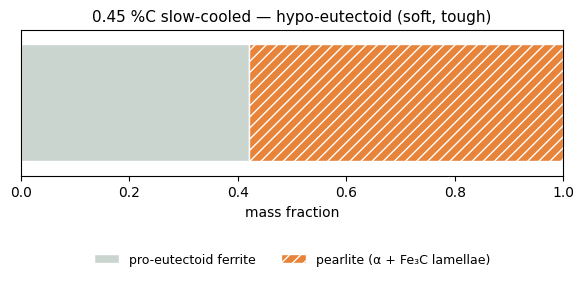

In [3]:
def show_equilibrium(carbon=0.45):
    # Slow-cooled constituents vs carbon — a direct fe_c.equilibrium_constituents call.
    c = fe_c.equilibrium_constituents(float(carbon))
    pro_color = PHASE_COLORS["pearlite"] if c.proeutectoid == "cementite" else "#cbd5d0"
    fig, ax = plt.subplots(figsize=(7, 1.9))
    ax.barh(0, c.f_proeutectoid, color=pro_color, edgecolor="white",
            label=f"pro-eutectoid {c.proeutectoid}")
    ax.barh(0, c.f_pearlite, left=c.f_proeutectoid, color=PHASE_COLORS["pearlite"],
            edgecolor="white", hatch="///", label="pearlite (α + Fe₃C lamellae)")
    ax.set_xlim(0, 1); ax.set_ylim(-0.5, 0.5); ax.set_yticks([])
    ax.set_xlabel("mass fraction")
    kind = "hypo-eutectoid (soft, tough)" if carbon < fe_c.C_EUTECTOID else \
           ("eutectoid (all pearlite)" if abs(carbon - fe_c.C_EUTECTOID) < 1e-9
            else "hyper-eutectoid (brittle Fe₃C network)")
    ax.set_title(f"{carbon:.2f} %C slow-cooled — {kind}", fontsize=11)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.45), ncol=2, frameon=False, fontsize=9)
    plt.show()

# Direct render (static, banked in the .ipynb).
show_equilibrium(0.45)

In [4]:
# Live: drag carbon across the eutectoid and watch the constituent network flip.
interact(show_equilibrium,
         carbon=widgets.FloatSlider(value=0.45, min=0.05, max=1.20, step=0.05,
                                    description="%C", continuous_update=True,
                                    style={"handle_color": KNOB}));

interactive(children=(FloatSlider(value=0.45, description='%C', max=1.2, min=0.05, step=0.05, style=SliderStyl…

## 2 · The mechanism: the TTT C-curve and *how fast* you cool

Slow cooling reaches equilibrium; a real quench does not. Undercooling below A₁
is the **driving force**, but diffusion needs *time* — so the
time-to-transform traces a **C-curve** (fast at the warm/cold extremes, slowest
at the **nose**). A cooling path that **misses the nose** has no time to form
pearlite and instead shears to hard, diffusionless **martensite** below Mₛ. Same
austenite, a spectrum of fates, set entirely by which side of the nose the path
falls — the project's anchor result
([`demo_four_curves`](demo_four_curves.py)), here over any real grade.

<details>
<summary><b>⌬ Going deeper — the crystal structures behind the story</b> &nbsp;(click to expand)</summary>

Everything above is really a story about **how iron atoms pack** and **where the carbon goes**.
Iron is *allotropic* — it changes crystal structure with temperature:

| Phase | Structure | Carbon it dissolves | Why |
|---|---|---|---|
| **Austenite (γ)** | **FCC** — face-centred cubic | up to **2.1 %** | close-packed, but its octahedral holes are *large* — carbon fits |
| **Ferrite (α)** | **BCC** — body-centred cubic | only **0.02 %** | looser packing, yet tiny distorted interstices — carbon barely fits |
| **Martensite (α′)** | **BCT** — body-centred *tetragonal* | all of it, **trapped** | BCC stretched along one axis by carbon it had no time to reject |

**This table is the whole hardness story.** You austenitize to reach FCC, which *dissolves* the
carbon. On cooling, iron wants to become BCC ferrite — which **can't hold that carbon** — so it
has to go somewhere, and *how fast you cool decides where*:

- **Slow** → carbon has time to diffuse out and segregate into **cementite (Fe₃C)**; ferrite +
  cementite lamellae = **pearlite** (soft — the §1 endpoint).
- **Fast** → no time to diffuse; the FCC→BCC shear happens anyway but the carbon stays **trapped**,
  stretching the lattice into **BCT martensite**. That trapped carbon + the lattice strain + a
  high dislocation density is *why martensite is hard*.

So "miss the nose → martensite" (§2) is really "cool too fast for the carbon to diffuse out." The
TTT C-curve is a **diffusion clock** — it measures whether carbon had time to leave before the
lattice flipped to BCC.

</details>

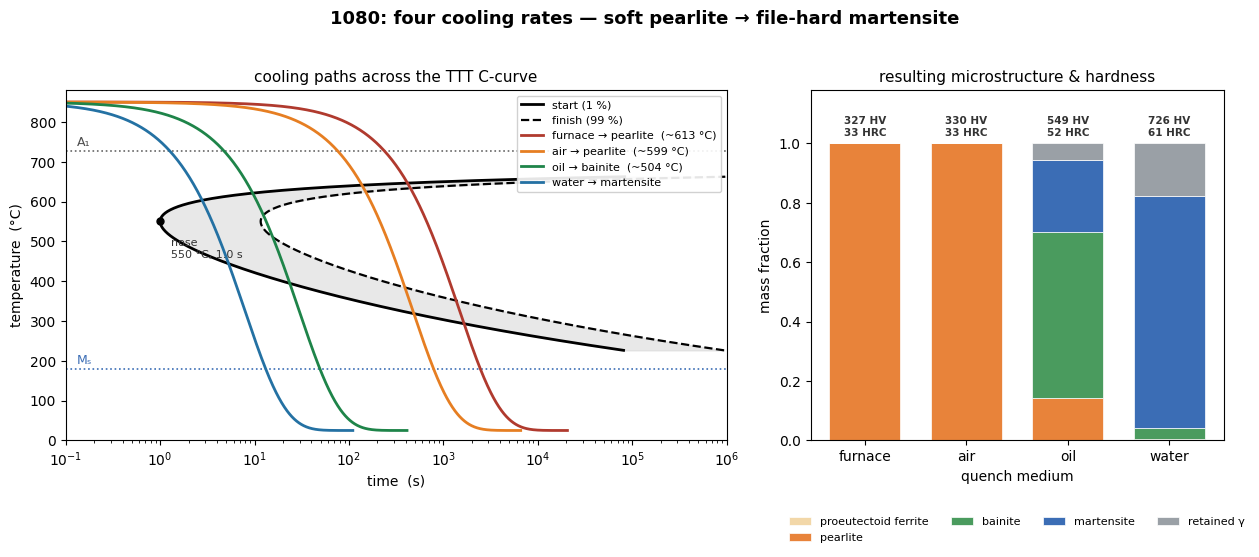

In [5]:
def four_curves(grade="1080"):
    # One steel, four quench rates across its TTT — direct sweep.cooling_rate_sweep.
    outs = sweep.cooling_rate_sweep(STEELS[grade], media=DEFAULT_MEDIA)
    fig = four_curves_figure(
        outs[0].ccurve,                       # same austenite → one C-curve
        [o.path for o in outs],
        [o.result for o in outs],
        hardness=[(o.HV, o.HRC) for o in outs],
        title=f"{STEELS[grade].label()}: four cooling rates — soft pearlite → file-hard martensite",
    )
    plt.show()

# Direct render (static, banked).
four_curves("1080")

In [6]:
interact(four_curves, grade=widgets.Dropdown(options=GRADES, value="1080", description="steel"));

interactive(children=(Dropdown(description='steel', index=1, options=('1045', '1080', '4140', '8620'), value='…

### Drag a single path across the C-curve

Pick one steel, one medium, one **section size** and watch *that* path fall
across the C-curve into its microstructure. Thicken the section or pick a steel
whose hardenability can't keep up and martensite gives way to pearlite. A severe
quench of a thick section trips the **Biot flag** — the honest cue that the 0-D
lumped cooler is stretched and the [Phase-2 spatial Jominy solve](jominy.py) is
what you actually want there.

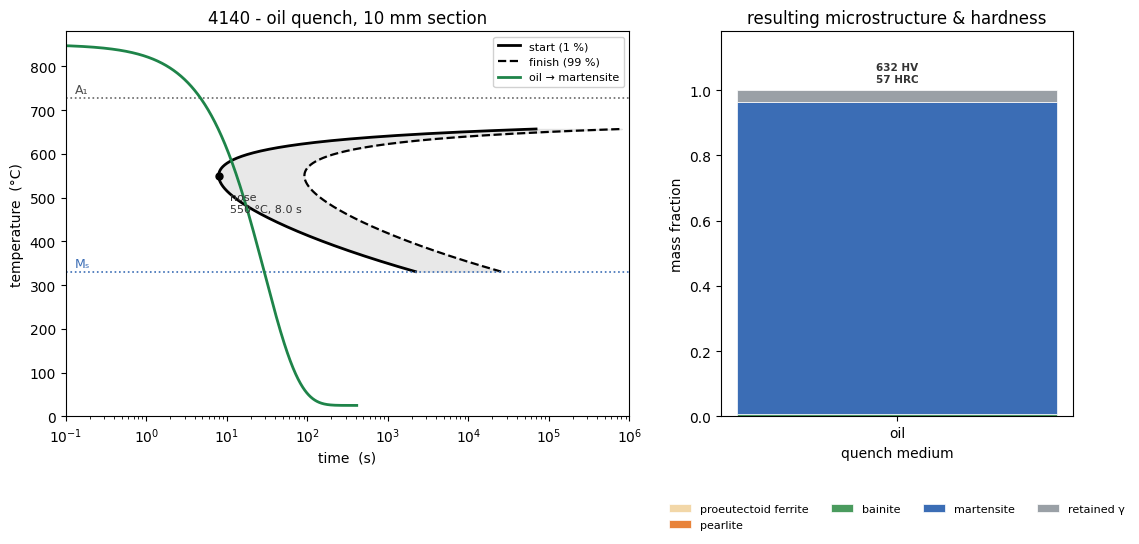

4140  oil  10 mm  →  martensite   632 HV / 57 HRC  ·  UTS off-scale (as-quenched, HV > 550)  ·  toughness 0.00


In [7]:
def what_if(grade="4140", medium="oil", section_mm=10.0):
    # One (steel, medium, section) what-if - a direct sweep.evaluate call.
    o = sweep.evaluate(STEELS[grade], medium=medium, diameter=float(section_mm) / 1000.0)
    fig, (ax_ttt, ax_bar) = plt.subplots(
        1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [1.6, 1.0]})
    plot_ttt(ax_ttt, o.ccurve)
    plot_cooling_paths(ax_ttt, [o.path], [o.result])
    ax_ttt.set_title(f"{STEELS[grade].label()} - {medium} quench, {section_mm:.0f} mm section")
    plot_microstructure_bars(ax_bar, [o.path], [o.result], hardness=[(o.HV, o.HRC)])
    ax_bar.set_title("resulting microstructure & hardness")
    hrc = f"{o.HRC:.0f} HRC" if np.isfinite(o.HRC) else "off HRC scale (soft)"
    UTS = prop.tensile_strength_MPa(o.HV)
    uts_s = f"{UTS:.0f} MPa" if np.isfinite(UTS) else "off-scale (as-quenched, HV > 550)"
    tough = prop.toughness_index(o.HV)
    flag = "" if o.lumped_valid else f"   ⚠ Bi = {o.biot:.2f} ≥ 0.1 → 0-D stretched (use the Jominy spatial solve)"
    plt.show()
    print(f"{STEELS[grade].label()}  {medium}  {section_mm:.0f} mm  →  "
          f"{o.dominant().replace('_', ' ')}   {o.HV:.0f} HV / {hrc}  ·  UTS {uts_s}  ·  toughness {tough:.2f}{flag}")

# Direct render (static, banked).
what_if("4140", "oil", 10.0)

In [8]:
interact(
    what_if,
    grade=widgets.Dropdown(options=GRADES, value="4140", description="steel"),
    medium=widgets.Dropdown(options=list(DEFAULT_MEDIA), value="oil", description="quench"),
    section_mm=widgets.FloatSlider(value=10.0, min=5.0, max=80.0, step=5.0,
                                   description="section mm", continuous_update=True,
                                   style={"handle_color": KNOB}),
);

interactive(children=(Dropdown(description='steel', index=2, options=('1045', '1080', '4140', '8620'), value='…

## 3 · Hardenability: the composition axis

The four-curves view fixes the steel and sweeps the rate. Flip it: fix the rate,
sweep the **composition**. Mn/Cr/Mo slide the whole C-curve to longer times, so
martensite survives a **slower** quench — the steel hardens **deeper**.

One honesty note baked into the 0-D model: a quench medium feeds *every* steel
the **same** cooling path (the lumped `T(t)` depends on the section and medium,
not composition), so the steels **share the martensitic fast end (water) and the
pearlitic slow end (furnace) and diverge only in the middle**. Read the alloy
trend at an *intermediate* medium (oil) — never at the saturated ends, where the
composition axis is silent.

<details>
<summary><b>⚗ Going deeper — what each alloying element actually does</b> &nbsp;(click to expand)</summary>

The sliders below give you C, Mn, Cr, Mo, Ni — but real steels are designed element by element.
Two families, by *how the atom sits in the iron lattice*:

- **Interstitial** (small atoms — **C, N**): squeeze into the gaps *between* iron atoms. A little
  goes a long way — large localized lattice strain → strong hardening per atom. Carbon is the
  master variable; free **nitrogen** also strengthens but **embrittles** (the `N_free` DBTT term
  in §5).
- **Substitutional** (Fe-sized — **Mn, Si, Cr, Mo, Ni, V**): *replace* iron atoms one-for-one.
  Milder per atom, but they set **phase stability** and **hardenability**.

| Element | What it buys you |
|---|---|
| **C** | the potential hardness (interstitial); austenite stabilizer |
| **Mn** | hardenability + deoxidizer; ties up sulfur as MnS; austenite stabilizer |
| **Cr** | hardenability + hard carbides (wear); **corrosion resistance** (stainless ≳ 11 %) |
| **Mo** | hardenability + **suppresses temper embrittlement** + high-temperature strength |
| **Ni** | hardenability + **toughness** (it *lowers* DBTT — opposite of Si); austenite stabilizer |
| **Si** | deoxidizer + solid-solution strength, but **raises DBTT** (the §5 Si term) |
| **V, Nb, Ti** | **grain refinement** + precipitation strengthening (microalloyed HSLA steels) |

**Austenite stabilizers** (Ni, Mn, C, N) widen the γ field — push enough (≈ 8 % Ni + 18 % Cr) and
you get *austenitic stainless*, FCC even at room temperature. **Ferrite stabilizers** (Cr, Si, Mo,
V, Ti) do the opposite. Note the toughness fork: **Ni lowers DBTT, Si raises it** — the *same*
"add a substitutional solute" move, opposite toughness outcome. The one lever that helps **both**
strength and toughness is **grain refinement** (§5) — which is exactly what the V/Nb/Ti row buys.

</details>

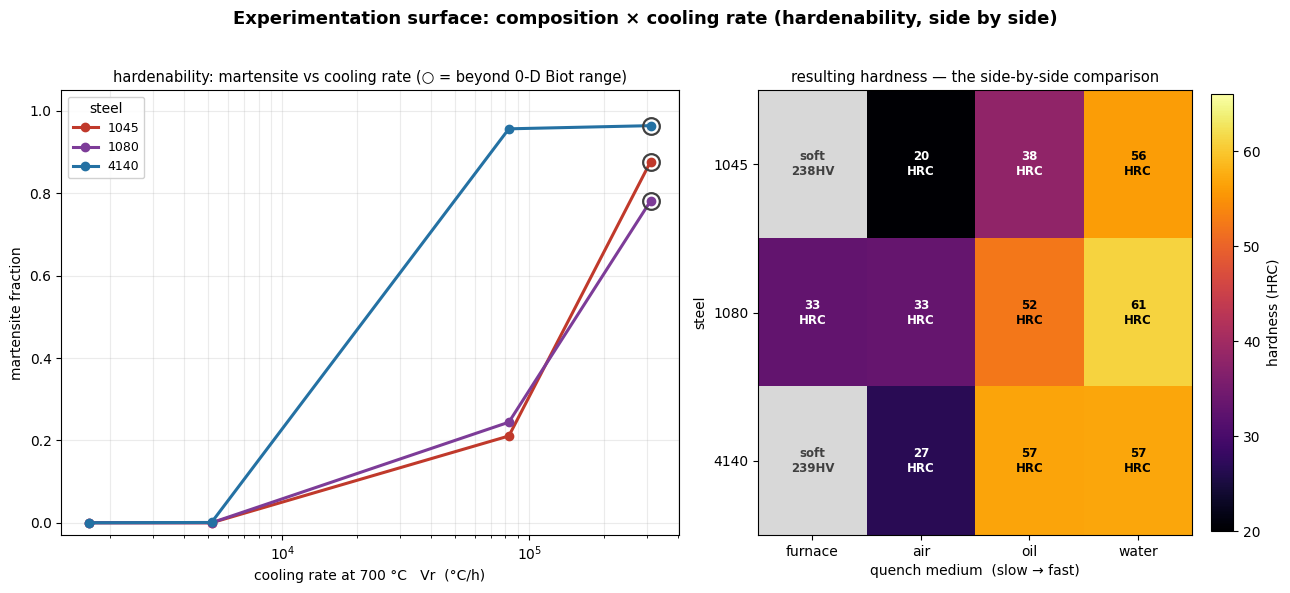

In [9]:
def compare(grades=("1045", "1080", "4140")):
    # Composition × cooling-rate grid — a direct sweep.sweep_grid call.
    grades = list(grades)
    if len(grades) < 2:
        print("pick at least two steels to compare"); return
    grid = sweep.sweep_grid(grades, media=DEFAULT_MEDIA)
    fig = sweep_comparison_figure(grid)
    plt.show()

# Direct render (static, banked).
compare(("1045", "1080", "4140"))

In [10]:
interact(
    compare,
    grades=widgets.SelectMultiple(options=GRADES, value=("1045", "1080", "4140"),
                                  description="steels", rows=4),
);

interactive(children=(SelectMultiple(description='steels', index=(0, 1, 2), options=('1045', '1080', '4140', '…

### Build your own steel — watch the C-curve move

The presets above are four real steels. Here you mix your *own*: dial the **carbon**
and the **alloying elements** (Mn, Cr, Mo, Ni) and two things update live.

**Left — the TTT C-curve.** This is the medium-independent view, so it *always*
responds: every bit of Cr/Mo/Mn slides the whole curve **right** (toward longer
times) — that *is* hardenability. The oil-quench path is drawn across it; when your
alloy pushes the nose far enough right that the path **misses** it, you get martensite.

**Right — the resulting microstructure** at an **oil** quench (the *discriminating*
medium — see the note above: at water everything is martensite and at furnace
everything is pearlite, so the composition axis only speaks in the middle). The swatch's
**areas are the computed phase fractions**; the grain *shapes* are illustrative. For real
grain-*size* physics — yield, DBTT, and the strength-toughness lever — see **§5** below.

*Honest range note:* the model is calibrated to the reference 1080 (Mn ≈ 0.7) and to
4140; very high alloy contents extrapolate beyond the validated envelope. Keep
**Mn ≳ 0.3** — a real plain-carbon steel still carries ~0.7 % Mn, so `Mn = 0` is a
leaner hypothetical the kinetics warn about. Reproduce the presets: **1045** ≈
C0.45/Mn0.75 · **4140** ≈ C0.40/Mn0.90/Cr1.0/Mo0.20 · **8620** ≈
C0.20/Mn0.80/Ni0.55/Cr0.50/Mo0.20.

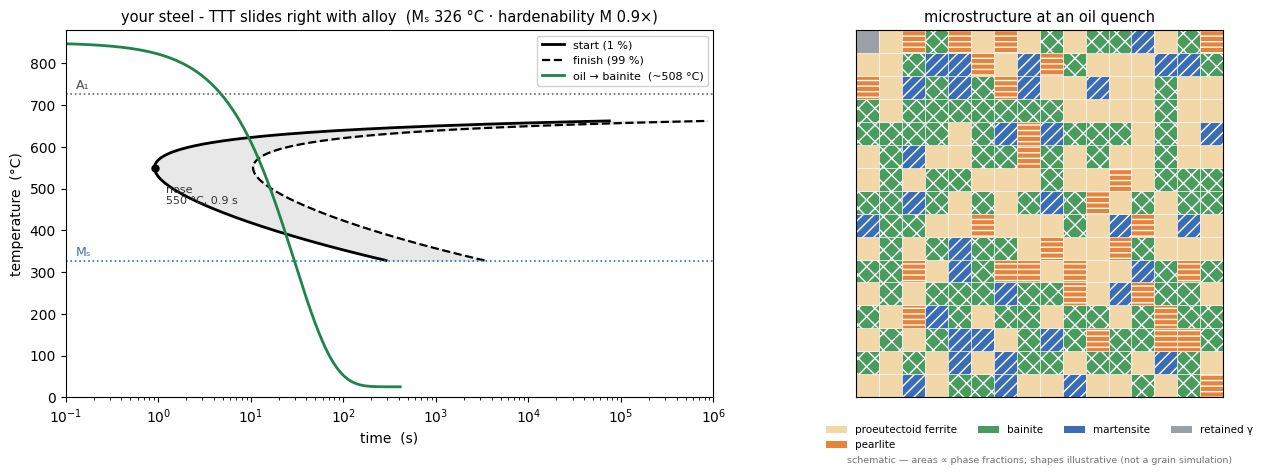

C 0.45 · Mn 0.75 · Cr 0.00 · Mo 0.00 · Ni 0.00   →   Mₛ 326 °C · hardenability M 0.9×
   oil quench →  13% martensite · 347 HV / 35 HRC · UTS 1105 MPa · toughness 0.63


In [11]:
def build_your_own(C=0.45, Mn=0.75, Cr=0.0, Mo=0.0, Ni=0.0):
    # A custom composition -> the full validated chain at a FIXED oil quench (the
    # discriminating medium). Direct sweep.evaluate(Steel(...)): the SAME harness the
    # presets use, driven by sliders instead of a dropdown.
    steel = sweep.Steel(C=float(C), Mn=float(Mn), Cr=float(Cr), Mo=float(Mo),
                        Ni=float(Ni), name="your steel")
    o = sweep.evaluate(steel, medium="oil")

    fig, (ax_ttt, ax_micro) = plt.subplots(
        1, 2, figsize=(13, 5.4), gridspec_kw={"width_ratios": [1.55, 1.0]})
    plot_ttt(ax_ttt, o.ccurve)
    plot_cooling_paths(ax_ttt, [o.path], [o.result])
    ax_ttt.set_title(f"your steel - TTT slides right with alloy  "
                     f"(Mₛ {o.ccurve.Ms:.0f} °C · hardenability M {o.ccurve.tau_factor:.1f}×)",
                     fontsize=10.5)
    microstructure_schematic(ax_micro, o.result.fractions(),
                             title="microstructure at an oil quench")

    UTS = prop.tensile_strength_MPa(o.HV)
    uts_s = f"{UTS:.0f} MPa" if np.isfinite(UTS) else "off-scale (as-quenched, HV > 550)"
    hrc_s = f"{o.HRC:.0f} HRC" if np.isfinite(o.HRC) else "off HRC scale (soft)"
    fig.subplots_adjust(left=0.06, right=0.97, bottom=0.20, wspace=0.22)
    plt.show()
    print(f"C {C:.2f} · Mn {Mn:.2f} · Cr {Cr:.2f} · Mo {Mo:.2f} · Ni {Ni:.2f}   →   "
          f"Mₛ {o.ccurve.Ms:.0f} °C · hardenability M {o.ccurve.tau_factor:.1f}×")
    print(f"   oil quench →  {o.result.martensite:.0%} martensite · {o.HV:.0f} HV / {hrc_s} · "
          f"UTS {uts_s} · toughness {prop.toughness_index(o.HV):.2f}")

# Direct render (static, banked in the .ipynb).
build_your_own(0.45, 0.75, 0.0, 0.0, 0.0)

In [12]:
interact(
    build_your_own,
    C=widgets.FloatSlider(value=0.45, min=0.10, max=1.00, step=0.05,
                          description="C %", continuous_update=True, style={"handle_color": KNOB}),
    Mn=widgets.FloatSlider(value=0.75, min=0.30, max=2.00, step=0.05,
                           description="Mn %", continuous_update=True, style={"handle_color": KNOB}),
    Cr=widgets.FloatSlider(value=0.0, min=0.0, max=2.00, step=0.05,
                           description="Cr %", continuous_update=True, style={"handle_color": KNOB}),
    Mo=widgets.FloatSlider(value=0.0, min=0.0, max=0.60, step=0.05,
                           description="Mo %", continuous_update=True, style={"handle_color": KNOB}),
    Ni=widgets.FloatSlider(value=0.0, min=0.0, max=2.00, step=0.05,
                           description="Ni %", continuous_update=True, style={"handle_color": KNOB}),
);

interactive(children=(FloatSlider(value=0.45, description='C %', max=1.0, min=0.1, step=0.05, style=SliderStyl…

### The critical diameter — hardenability as a bar size, checked against measured steel

§3's four-curves view reads hardenability as a C-curve that slides right with alloy. The same idea has a more tangible form: the **critical diameter** `D_c` — the round-bar size that comes out 50 % martensite at its **centre**. A bigger `D_c` means a deeper-hardening steel. Here the model computes `D_c` for four grades (from `fM = 0.5`, reported as the water-quench centre-equivalent) and lays it beside **measured** hardenability bands (SAE J1268 / EMJ H-bands — *measured*, not Grossmann-calculated, so this is a genuine cross-check and not the model grading itself).

The read, strongest first: the **ranking is correct** — `1045 < 8620 < 4140 < 4340` — *alloy beats carbon* for depth, which is the whole point of hardenability. **4340 is under-predicted** (its Ni potency is under-captured by the Cr-Mo-calibrated scale — an honest miss, the clean tooth). **4140** sits inside its band *by construction* (it is the calibration anchor, so a match there is not evidence). Banked artifact: [`demo_ideal_diameter`](demo_ideal_diameter.py).

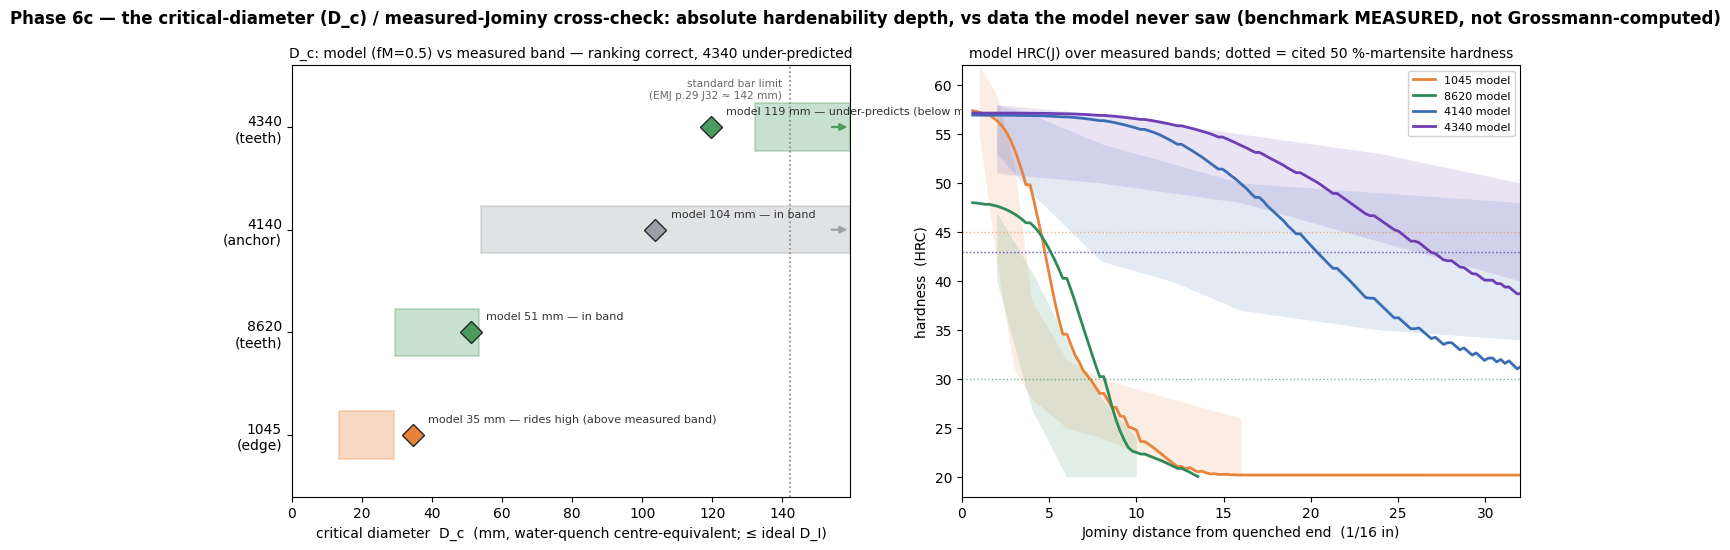

hardenability ranking (model D_c): 1045 < 8620 < 4140 < 4340  -- alloy beats carbon (the correct order)
   1045  (edge  )  model     35 mm  vs measured  13-  29 mm  -> rides high (above measured band)
   8620  (teeth )  model     51 mm  vs measured  30-  53 mm  -> in band
   4140  (anchor)  model    104 mm  vs measured  54->bar mm  -> in band
   4340  (teeth )  model    119 mm  vs measured 132->bar mm  -> under-predicts (below measured band)
4140 = the calibration anchor (in-band by construction, NOT teeth); 4340 under-predicted (Ni potency). Measured bands are cited anchors; no new physics -- the Jominy chain, read as a diameter.


In [ ]:
from steel.demo_ideal_diameter import compute as dc_compute
from steel.plots import ideal_diameter_figure

d = dc_compute()                                    # the cross-check vs measured H-bands (banked static)
ideal_diameter_figure(d)
plt.show()

di = {n: d.checks[n].model.Dc_mm for n in d.order}
ranked = " < ".join(sorted(di, key=lambda n: di[n]))
print(f"hardenability ranking (model D_c): {ranked}  -- alloy beats carbon (the correct order)")
for n in d.order:
    cc = d.checks[n]; me = cc.measured
    mdi = "off-scale" if not np.isfinite(cc.model.Dc_mm) else f"{cc.model.Dc_mm:4.0f} mm"
    hi = ">bar" if me.upper_off_scale else f"{me.Dc_max_mm:.0f}"
    print(f"   {n:5s} ({cc.role:6s})  model {mdi:>9}  vs measured {me.Dc_min_mm:3.0f}-{hi:>4} mm  -> {cc.verdict}")
print("4140 = the calibration anchor (in-band by construction, NOT teeth); 4340 under-predicted "
      "(Ni potency). Measured bands are cited anchors; no new physics -- the Jominy chain, read as a diameter.")

## 4 · Tempering: trading hardness back for toughness

As-quenched martensite is hard but brittle — almost every real part is then
**tempered** (reheated, sub-A₁) to recover toughness at some cost in hardness.
The **Hollomon–Jaffe** parameter `P = T·(C_hj + log₁₀ t)` collapses temperature and
time into one knob; hardness slides down a master curve as `P` rises, and
strength/toughness follow ([`properties`](properties.py), §3b). This is the
**martensite-only** quench-and-temper response (the validated scope), so it gets
its own sweep — an alloy steel **resists softening** as an emergent consequence
of starting harder *and* flooring higher.

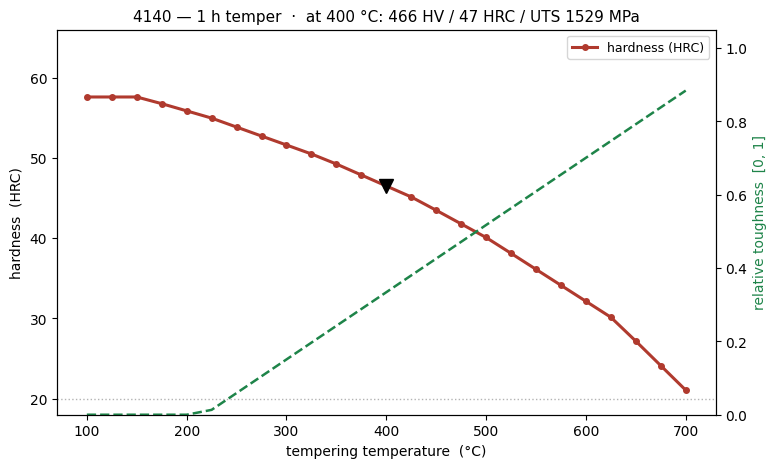

In [13]:
def temper(grade="4140", t_hours=1.0, mark_T=400.0):
    # Quench-and-temper response — direct sweep.temper_sweep + a properties readout.
    steel = STEELS[grade]
    tr = sweep.temper_sweep(steel, t_hours=float(t_hours))
    finite = np.isfinite(tr.HRC)

    fig, ax = plt.subplots(figsize=(8.5, 5))
    ax.plot(tr.temper_C[finite], tr.HRC[finite], "-o", color="#b03a2e", ms=4, lw=2.2,
            label="hardness (HRC)")
    ax.axhline(prop.RELIABLE_HRC_MIN, color="0.7", ls=":", lw=1.0)
    ax.set_xlabel("tempering temperature  (°C)"); ax.set_ylabel("hardness  (HRC)")
    ax.set_ylim(prop.RELIABLE_HRC_MIN - 2, 66)
    ax_t = ax.twinx()
    ax_t.plot(tr.temper_C, tr.toughness, "--", color="#1e8449", lw=1.8, label="toughness (rel.)")
    ax_t.set_ylabel("relative toughness  [0, 1]", color="#1e8449"); ax_t.set_ylim(0, 1.05)

    # The marked point — a direct properties call (not interpolated from the sweep).
    HV = prop.tempered_martensite_HV(steel.C, float(mark_T), float(t_hours), comp=steel.minor())
    HRC = prop.vickers_to_rockwell_c(HV)
    UTS = prop.tensile_strength_MPa(HV)
    if np.isfinite(HRC):
        ax.plot([mark_T], [HRC], "kv", ms=10, zorder=5)
    uts_s = f"{UTS:.0f} MPa" if np.isfinite(UTS) else "off-scale (HV > ~550)"
    hrc_s = f"{HRC:.0f} HRC" if np.isfinite(HRC) else "off HRC scale"
    ax.set_title(f"{steel.label()} — {t_hours:g} h temper  ·  at {mark_T:.0f} °C: "
                 f"{HV:.0f} HV / {hrc_s} / UTS {uts_s}", fontsize=11)
    ax.legend(loc="upper right", fontsize=9)
    plt.show()

# Direct render (static, banked).
temper("4140", 1.0, 400.0)

In [14]:
interact(
    temper,
    grade=widgets.Dropdown(options=GRADES, value="4140", description="steel"),
    t_hours=widgets.FloatSlider(value=1.0, min=0.25, max=10.0, step=0.25,
                                description="time (h)", continuous_update=True,
                                style={"handle_color": KNOB}),
    mark_T=widgets.FloatSlider(value=400.0, min=100.0, max=700.0, step=25.0,
                               description="temper °C", continuous_update=True,
                               style={"handle_color": KNOB}),
);

interactive(children=(Dropdown(description='steel', index=2, options=('1045', '1080', '4140', '8620'), value='…

## 5 · Grain size: the strength-and-toughness lever (Phase 5)

Everything above maps a cooling path to **hardness**. The one structural quantity the
hardness chain never carried is the **grain size** — and through it the two engineering
properties `properties.py` deliberately withholds: **yield strength** (Hall–Petch) and
the **ductile-brittle transition temperature (DBTT)**.

Before you cool, you **austenitize**: soak the part hot so the carbon dissolves. Soak
**hotter or longer** and the austenite grains *grow*
([`grain.austenite_grain_size`](grain.py), Phase 5a); a finer austenite grain seeds a
finer **ferrite** grain, and the two cited [Pickering laws](grain.py) move in **opposite**
directions with grain size:

- **yield**&nbsp;&nbsp;`σ_y = … + k·d^(−½)`&nbsp;&nbsp;— refine the grain → **stronger**
- **DBTT**&nbsp;&nbsp;`= … − k·d^(−½)`&nbsp;&nbsp;— refine the grain → **tougher** (lower transition)

So **grain refinement is the lone lever that raises strength *and* toughness at once** —
and **over-austenitizing** (too hot / too long) coarsens the grain and costs you *both*.
Drag the austenitizing temperature below and watch the DBTT climb across **room
temperature**: a part that was ductile in the hand turns brittle.

> **Honest scope.** This is the **normalized / slow-cooled** ferrite-pearlite regime
> (equilibrium pearlite from carbon, at a *fixed* cooling rate) — **not** the quenched
> martensite of §1–§4 (the laws return `nan` for a martensitic structure). And the
> co-benefit / over-austenitizing **directions** are true *by construction* from the two
> cited Pickering signs — a **demonstration**, not evidence; Phase 5's only falsifiable
> teeth are 5a's grain-growth holdout (`test_grain.py`). The full three-panel artifact
> (co-benefit · lever plane · overheating penalty) is [`demo_grain`](demo_grain.py).

<details>
<summary><b>🔬 Going deeper — why grain refinement uniquely improves <i>both</i></b> &nbsp;(click to expand)</summary>

§5's headline — refinement raises strength *and* toughness — comes from grain boundaries playing
**two roles at once**:

1. **They block dislocations** (the carriers of plastic flow): a dislocation gliding through a
   grain piles up at the boundary, and the next grain's differently-oriented slip planes resist
   it. More boundary area (finer grain) → **higher yield**. That's Hall–Petch
   `σ_y = σ₀ + k·d^(−½)` — the **positive** grain term.
2. **They deflect and arrest cleavage cracks** (the carriers of brittle fracture): a running
   crack must change direction at every misoriented boundary, which costs energy. Finer grain →
   harder to propagate a brittle crack → **lower DBTT** — the **negative** grain term.

The *same* feature — grain-boundary area — helps both, which is why grain refinement escapes the
usual strength↔toughness trade-off. Every *other* strengthening lever (more carbon, more pearlite,
solid solution) adds obstacles *inside* the grain — raising strength but giving cleavage an easier
path, so toughness falls. (That trade-off asymmetry is the **lever comparison** drawn in the banked
*three-panel* figure, [`demo_grain`](demo_grain.py); the interactive figure below shows the grain
*growing* with temperature and the resulting yield / DBTT.)

**In practice:** keep the austenitizing temperature low (the slider below), and add
**microalloying** — tiny amounts of **V, Nb, Ti** form carbonitride particles that *pin* the
austenite grain boundaries and stop them coarsening during the soak. That is the design idea
behind modern HSLA (high-strength low-alloy) steels — and the S960MC grade whose grain-growth
data calibrates §5's kinetics ([`grain.py`](grain.py)).

</details>

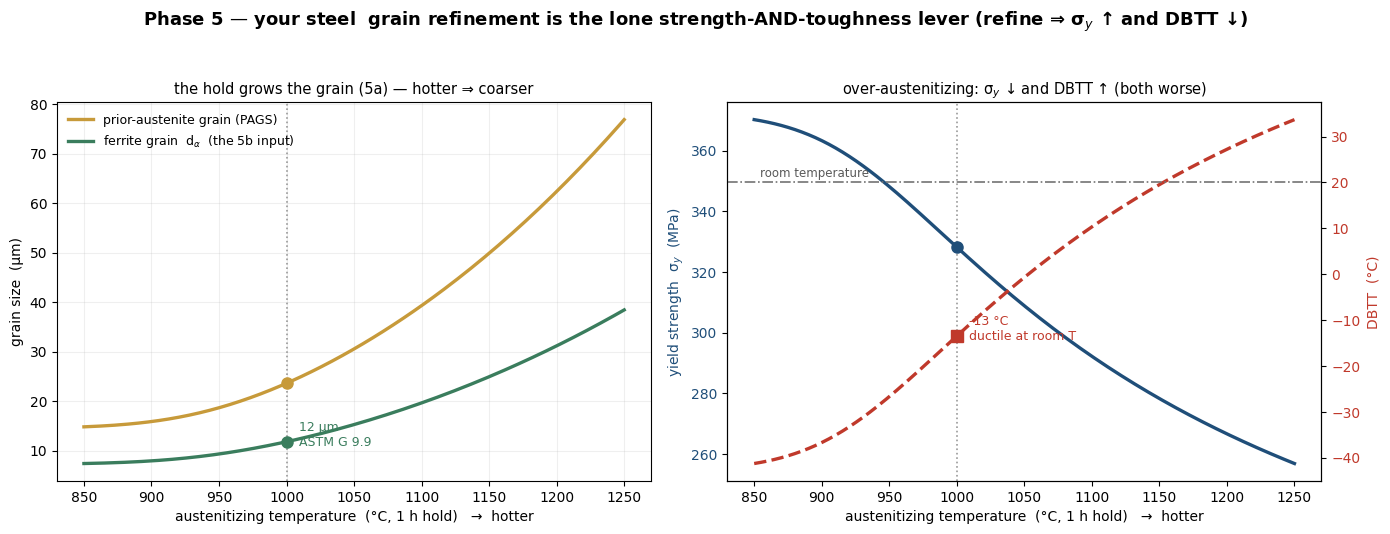

austenitize 1000 °C / 1 h  →  PAGS 24 µm  →  ferrite 12 µm (ASTM G 9.9)
   yield σ_y 328 MPa  ·  DBTT -13 °C  →  ductile at room T (20 °C)  ·  equilibrium pearlite 24% from 0.20 %C


In [15]:
def grain_explorer(aust_T=1000.0, hold_h=1.0, C=0.20, Mn=0.75, Si=0.20):
    # Austenitize (T, t) + composition -> the coupled Phase-5 chain
    # (grain.coupled_grain_properties): PAGS (5a) -> ferrite grain (the coupling) ->
    # yield + DBTT (5b). The render layer owns the figure; this cell only turns the knobs.
    comp = {"Mn": float(Mn), "Si": float(Si)}
    gp = grain.coupled_grain_properties(float(aust_T), float(hold_h), float(C), comp=comp)
    grain_interactive_figure(gp, float(C), comp, name="your steel", t_hours=float(hold_h))
    plt.show()                                   # figure FIRST, then the readout (flicker-safe)
    G_ferrite = grain.astm_grain_size_number(gp.ferrite_um)
    verdict = "BRITTLE at room T" if gp.dbtt_C > grain.ROOM_TEMPERATURE_C else "ductile at room T"
    print(f"austenitize {aust_T:.0f} °C / {hold_h:g} h  →  PAGS {gp.pags_um:.0f} µm  →  "
          f"ferrite {gp.ferrite_um:.0f} µm (ASTM G {G_ferrite:.1f})")
    print(f"   yield σ_y {gp.yield_MPa:.0f} MPa  ·  DBTT {gp.dbtt_C:.0f} °C  →  {verdict} (20 °C)  ·  "
          f"equilibrium pearlite {gp.f_pearlite:.0%} from {C:.2f} %C")

# Direct render (static, banked in the .ipynb).
grain_explorer(1000.0, 1.0, 0.20, 0.75, 0.20)

In [16]:
interact(
    grain_explorer,
    aust_T=widgets.FloatSlider(value=1000.0, min=850.0, max=1250.0, step=25.0,
                               description="austenitize °C", continuous_update=True,
                               style={"handle_color": KNOB}),
    hold_h=widgets.FloatSlider(value=1.0, min=0.25, max=8.0, step=0.25,
                               description="hold (h)", continuous_update=True,
                               style={"handle_color": KNOB}),
    C=widgets.FloatSlider(value=0.20, min=0.05, max=0.80, step=0.05,
                          description="C %", continuous_update=True, style={"handle_color": KNOB}),
    Mn=widgets.FloatSlider(value=0.75, min=0.0, max=2.00, step=0.05,
                           description="Mn %", continuous_update=True, style={"handle_color": KNOB}),
    Si=widgets.FloatSlider(value=0.20, min=0.0, max=1.00, step=0.05,
                           description="Si %", continuous_update=True, style={"handle_color": KNOB}),
);

interactive(children=(FloatSlider(value=1000.0, description='austenitize °C', max=1250.0, min=850.0, step=25.0…

### See it: the grain, drawn to scale

The figure above plots what grain refinement *buys* (yield&nbsp;↑, DBTT&nbsp;↓). Here is what it
*looks like* — the **same grain size**, rendered as a size-accurate **Voronoi swatch**. A cool vs a
hot austenitize gives a fine vs a coarse ferrite grain, drawn in **one common field of view**, so
over-austenitizing reads as *fewer, larger* grains in the same area.

The one faithful quantity is the grain **number density** — grains per area = the ASTM
`Nₐ = 1/d²` that [`grain.py`](grain.py) already computes, so a finer grain packs
`(d_coarse / d_fine)²` times as many cells into the field. The individual cell *shapes* are
illustrative: it complements the phase-fraction swatch of §3 and is **not** a micrograph. Banked
artifact: [`demo_grain_morphology`](demo_grain_morphology.py).

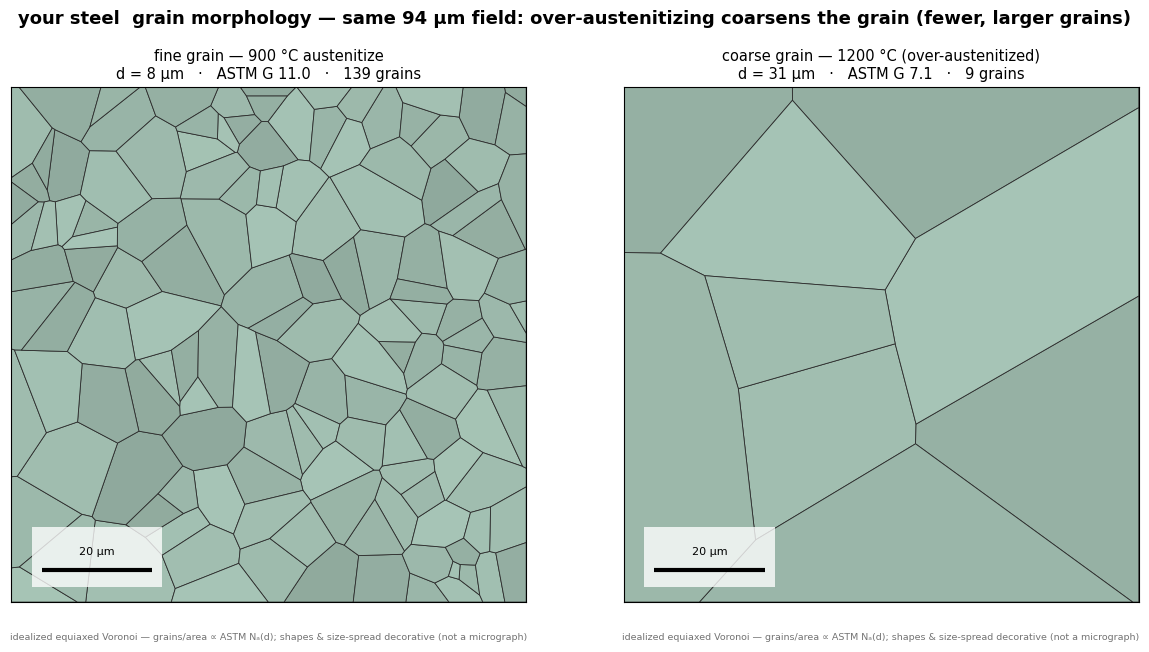

cool 900 °C → ferrite 8 µm (ASTM G 11.0)   |   hot 1200 °C → ferrite 31 µm (ASTM G 7.1)
   same field of view → the cool grain shows ~15× as many grains as the hot one (grains/area ∝ 1/d²). That finer mosaic is BOTH stronger and tougher (the §5 payoff above).


In [21]:
from steel.plots import grain_morphology_figure

def grain_morphology(aust_cool=900.0, aust_hot=1200.0, hold_h=1.0):
    # Grain SIZE depends only on the austenitizing hold (T, t) - not composition - so this
    # size-accurate swatch has just those knobs. A cool vs a hot soak -> a fine vs a coarse
    # ferrite grain, drawn as Voronoi swatches in ONE common field of view (grains/area =
    # grain.py's ASTM N_A = 1/d^2). Direct grain.coupled_grain_properties calls; the render
    # layer owns the figure (plots.grain_morphology_figure). Reach, not evidence (ADR 0002).
    comp = {"Mn": 0.75, "Si": 0.20}
    fine = grain.coupled_grain_properties(float(aust_cool), float(hold_h), 0.20, comp=comp)
    coarse = grain.coupled_grain_properties(float(aust_hot), float(hold_h), 0.20, comp=comp)
    grain_morphology_figure(fine, coarse, name="your steel")
    plt.show()
    rf = (coarse.ferrite_um / fine.ferrite_um) ** 2
    Gc = grain.astm_grain_size_number(fine.ferrite_um)
    Gh = grain.astm_grain_size_number(coarse.ferrite_um)
    print(f"cool {aust_cool:.0f} \u00b0C \u2192 ferrite {fine.ferrite_um:.0f} \u00b5m (ASTM G {Gc:.1f})"
          f"   |   hot {aust_hot:.0f} \u00b0C \u2192 ferrite {coarse.ferrite_um:.0f} \u00b5m (ASTM G {Gh:.1f})")
    print(f"   same field of view \u2192 the cool grain shows ~{rf:.0f}\u00d7 as many grains as the hot "
          f"one (grains/area \u221d 1/d\u00b2). That finer mosaic is BOTH stronger and tougher (the \u00a75 payoff above).")

# Direct render (static, banked in the .ipynb).
grain_morphology(900.0, 1200.0, 1.0)

## 6 · Austempering: stop *inside* the diagram and grow bainite (Phase 6d)

§2's quench races *through* the C-curve; austempering **stops inside it**: quench (in a salt
bath) past the pearlite nose to a temperature between **Mₛ** and **Bₛ**, **hold** until the
austenite transforms isothermally to **bainite**, then cool. No brittle as-quenched martensite
ever forms, so there is nothing to temper — and the part barely distorts. Springs, clips and
high-carbon strip are made this way; **1080 is *the* classic austempering steel**.

The kinetics are Phase 6b's cited bainite reaction ([`kinetics.BainiteReaction`](kinetics.py)) —
which 6b *proved* must stay **out** of the continuous-cooling race — **anchored per steel to one
cited point** of the US Steel *Atlas of Isothermal Transformation Diagrams* (1951). Anchored at
371.1 °C only, the model predicts 1080's measured 50 %-line at the other atlas temperatures
within ~6 % ([`test_austemper`](tests/test_austemper.py) — the holdout teeth); the left panel
below shows those measured points sitting on the model's line.

**The exercise:** at your hold temperature, find the **shortest hold that still fully
transforms** (the marked *minimum full-transform hold*). Shorter → leftover austenite shears to
brittle untempered martensite on the final cool (watch the hardness jump); longer → nothing
gained.

> **Honest scope.** Only the two atlas-anchored steels are offered — the anchoring probe
> *falsified* the cited cross-composition arithmetic (wrong-signed: the atlas measures 4340
> ~5× *slower* than 1080 where the coefficients say ~7× *faster*), so each steel carries its
> own cited anchor and there is deliberately **no build-your-own** here. Claims stop at the
> atlas **50 % line** (the model's begin→50 % spacing runs wide — drawn dashed, named); the
> quench to the hold is idealized **instantaneous**; the un-modeled ferrite/pearlite race is
> **policed** (a printed warning near Bₛ), not modeled; bainite hardness is the **carbon-only
> placeholder, now load-bearing** (fine for plain-carbon 1080, under-ranks alloyed bainite).
> The banked artifact is [`demo_austemper`](demo_austemper.py).

<details>
<summary><b>⚙ Going deeper — why a bainite hold beats quench-and-temper (when it fits)</b> &nbsp;(click to expand)</summary>

**The problem with a hard quench** is the *path*: the surface hits Mₛ while the core is still
hot, so martensite forms in shells, each expanding (~4 % by volume) against the others — quench
stresses, distortion, sometimes cracks. Then the brittle as-quenched part needs a second furnace
trip (§4's temper) before it is usable.

**Austempering sidesteps both.** The salt bath holds the *whole* section at one temperature, so
the transformation happens nearly simultaneously everywhere — and at a temperature where the
product (bainite) is already a tough ferrite + carbide aggregate, not carbon-trapped martensite.
One furnace trip, low distortion, no temper. The price: the hold must outlast the bainite
reaction (minutes, vs seconds for a quench through), the section must be thin enough for the
salt bath to win the race down to the hold, and the hardness ceiling is bainite's — below
as-quenched martensite's.

**Upper vs lower bainite** (narrated — the model computes only the *fraction*): hold high in
the window and carbides precipitate *between* coarse ferrite laths (upper bainite, softer);
hold low, near Mₛ, and they precipitate *inside* fine laths (lower bainite — strength
approaching tempered martensite, with better toughness). The classic spring recipe holds low:
that is why the slider below defaults to ~343 °C (650 °F), the salt-bath classic.

</details>

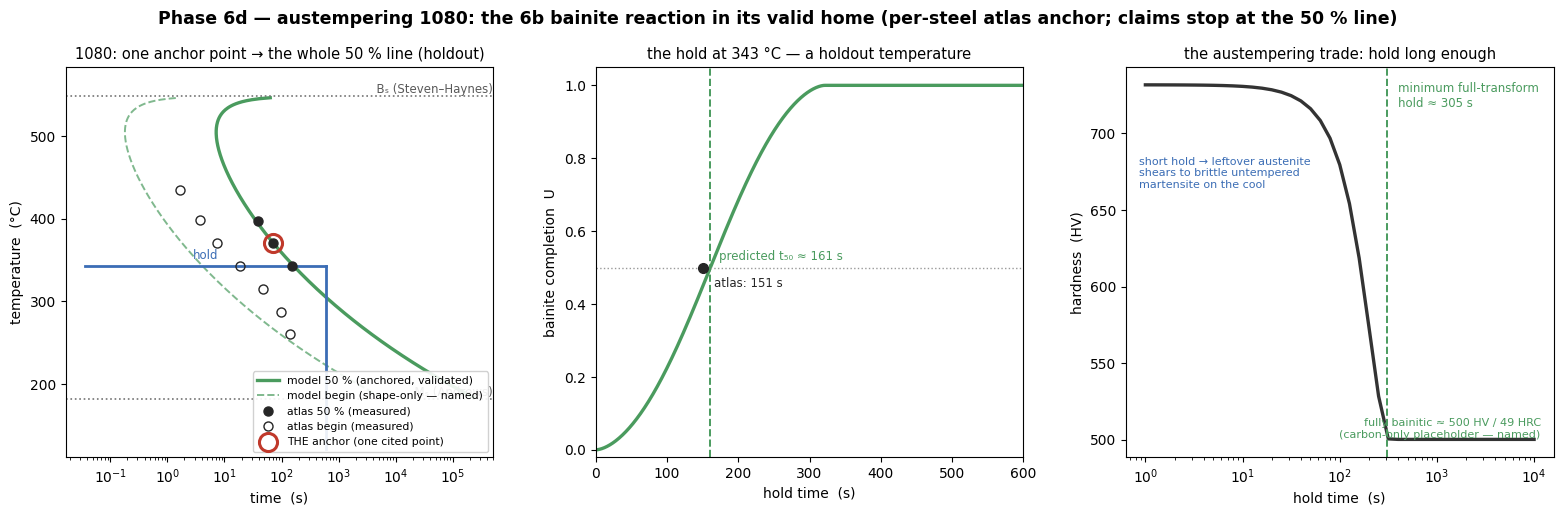

1080 austempered 600 s @ 343 °C  (window Mₛ 182 < T < Bₛ 548 °C)
   bainite 100% · martensite 0% · retained γ 0%  →  500 HV ≈ 49 HRC
   model 50 % at 161 s (atlas measured: 151 s) · minimum full-transform hold ≈ 305 s


In [17]:
from steel import austemper as aus
from steel.demo_austemper import compute as austemper_compute
from steel.plots import austemper_figure
import warnings

def austemper_explorer(steel="1080", T_hold=343.3, hold_s=600.0):
    # Anchored steel + hold -> the Phase-6d recipe (austemper.austemper), via the demo's
    # validated compute pipeline; the render layer owns the figure. The pearlite-race
    # UserWarning is folded into the printed verdict instead of console noise.
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="high hold", category=UserWarning)
        d = austemper_compute(steel, float(T_hold), float(hold_s))
    austemper_figure(d)
    plt.show()                                   # figure FIRST, then the readout (flicker-safe)
    h = d.hold
    hrc = f"{h.HRC:.0f} HRC" if np.isfinite(h.HRC) else "(off HRC scale)"
    print(f"{steel} austempered {hold_s:g} s @ {T_hold:.0f} °C  "
          f"(window Mₛ {h.Ms:.0f} < T < Bₛ {h.Bs:.0f} °C)")
    print(f"   bainite {h.bainite:.0%} · martensite {h.martensite:.0%} · "
          f"retained γ {h.retained_austenite:.0%}  →  {h.HV:.0f} HV ≈ {hrc}")
    atlas = f" (atlas measured: {d.measured_t50_here:.0f} s)" if np.isfinite(d.measured_t50_here) else ""
    print(f"   model 50 % at {d.predicted_t50_here:,.0f} s{atlas} · "
          f"minimum full-transform hold ≈ {d.min_full_hold:,.0f} s")
    if h.pearlite_race_flagged:
        print(f"   ⚠ high hold: the un-modeled ferrite/pearlite race would reach "
              f"~{h.pearlite_shadow:.0%} this close to Bₛ — the bainite-only claim is "
              f"unreliable here; hold lower, in the anchored band.")

# Direct render (static, banked in the .ipynb) — the classic 1080 recipe at a HOLDOUT
# temperature (343.3 °C = 650 °F; the anchor is 371.1 °C).
austemper_explorer("1080", 343.3, 600.0)

In [18]:
# Bounds 310-480 °C sit inside BOTH steels' (Ms, Bs) windows (1080: 192-548;
# 4340: 294-497), so every reachable hold is a valid austemper — the guards never fire.
interact(
    austemper_explorer,
    steel=widgets.Dropdown(options=list(aus.ATLAS_STEELS), value="1080", description="steel"),
    T_hold=widgets.FloatSlider(value=343.3, min=310.0, max=480.0, step=1.0,
                               description="hold °C", continuous_update=False,
                               style={"handle_color": KNOB}),
    hold_s=widgets.FloatLogSlider(value=600.0, base=10, min=0.0, max=4.0, step=0.05,
                                  readout_format=".0f", description="hold (s)",
                                  continuous_update=False, style={"handle_color": KNOB}),
);

interactive(children=(Dropdown(description='steel', options=('1080', '4340'), value='1080'), FloatSlider(value…

## 6b · The bainite bay: three competing reactions, opened in continuous cooling (§19)

Every section so far treats the diffusional transformation as **one** C-curve — pearlite above Bₛ, bainite below it — slid right for alloy steels by a single hardenability factor. That is the **validated workhorse**: it carries the four-curves and Jominy benchmarks and works for *any* composition. But it cannot show the real **bainite bay** — the temperature window where alloying pushes the *reconstructive* ferrite and pearlite reactions far to the right while barely moving the *displacive* bainite reaction, leaving a gap a cooling path can thread into bainite.

This view opens that bay, by racing **three separate** cited Kirkaldy–Venugopalan reactions — ferrite, pearlite and bainite — for one shared austenite pool. The separation is a **prediction, not a fit**: the published composition factors alone give `PC(4340)/PC(1080) ≈ 1400×` (pearlite, ≈ the atlas-measured ~10³×) while `BC` barely moves bainite. So **4340** (left, below) opens a wide bay — an intermediate cool lands **bainite-dominant**, the structure the single curve cannot produce — while **1080** (right) opens *no* bay: its pearlite and bainite noses nearly coincide, so the only route to bulk bainite is the isothermal **hold** of §6 (which is exactly why austempering exists).

<details>
<summary><b>⚙ Why both models exist — and the limits of each</b> &nbsp;(click to expand)</summary>

They are **not rivals to choose between** — the single curve stays the taught, validated default; this is a mechanism-deepening *lens* on the same physics.

|   | single-curve pipeline (§1–§5) | unified-KV view (this section) |
|---|---|---|
| reactions | one C-curve, pearlite/bainite split by temperature | three competing KV reactions on a shared pool |
| scope | **any** composition | the **two atlas-anchored steels** (1080, 4340) only |
| bainite time base | rides the one Grossmann shift | **per-steel atlas anchor** (cited absolute time) |
| what's validated | the four-curves + 1045/4140 Jominy benchmarks | the cited `FC`/`PC`≫`BC` *differential* (the teeth) |
| the bay in CCT | absent (single nose) | **demonstrated**, bridged from the isothermal atlas |

**The limits, named.** The cited cross-composition bainite arithmetic is **wrong-signed** (`BC` says 4340 bainite is *faster* than 1080; the atlas measures it *slower*) — so bainite *must* be anchored per steel, and there is **no cross-steel prediction** (the 8620 carbon-spread wall, Phase 6b). The atlas is **isothermal**: the bay *opening in continuous cooling* is bridged by Scheil additivity, with **no measured-CCT validation**. Carbon enrichment from ferrite is first-order (it lowers the effective Mₛ, printed below). Bainite hardness is the carbon-only placeholder (under-ranks alloyed bainite). The banked artifact is [`demo_unified_kv`](demo_unified_kv.py).

</details>

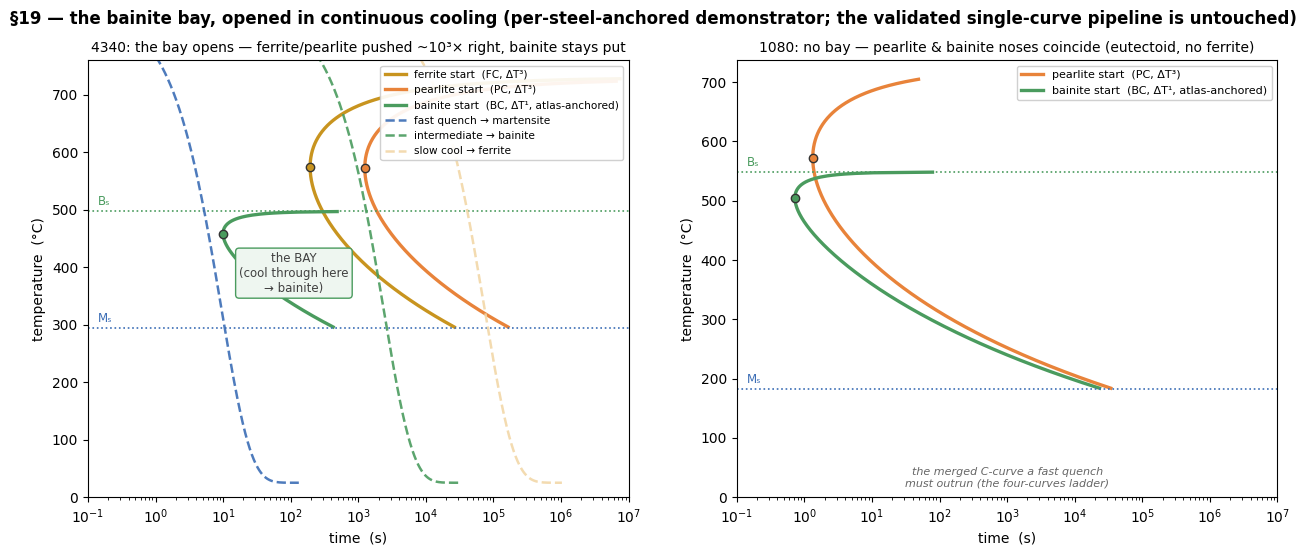

4340 — the bay opens: the pearlite nose (1,248 s) sits ×125 later than the bainite nose (10 s) — the cited PC≫BC differential. One steel, three cooling rates:
   fast quench   (Vr=  71.66 K/s)  →  MARTENSITE   (bainite 0%)
   intermediate  (Vr=   0.29 K/s)  →  BAINITE      (bainite 62%)
   slow cool     (Vr=   0.01 K/s)  →  FERRITE      (bainite 17%)
1080 — no bay: pearlite nose 1.3 s ≈ bainite 0.7 s (coincident). No continuous cool reaches bainite-dominant — the only route to bulk bainite is the isothermal hold (§6). The single-curve pipeline above stays the validated workhorse for every composition.


In [ ]:
from steel.demo_unified_kv import compute as unified_compute
from steel.plots import unified_kv_figure

# Light: the demo's compute pipeline (3 cooling paths + the two steels' competing C-curves) —
# NOT a rate sweep (a heavy cell is the documented notebook-kernel hazard). Banked static.
d = unified_compute()
unified_kv_figure(d)
plt.show()                                          # figure first, then the readout

b = d.bay
sep = b.pearlite_nose[1] / b.bainite_nose[1]
print(f"4340 — the bay opens: the pearlite nose ({b.pearlite_nose[1]:,.0f} s) sits "
      f"×{sep:.0f} later than the bainite nose ({b.bainite_nose[1]:.0f} s) "
      f"— the cited PC≫BC differential. One steel, three cooling rates:")
for p in d.paths:
    print(f"   {p.label:13s} (Vr={p.Vr:7.2f} K/s)  →  {p.dominant.replace('_',' ').upper():11s}"
          f"  (bainite {p.fractions['bainite']:.0%})")
nbv = d.nobay
print(f"1080 — no bay: pearlite nose {nbv.pearlite_nose[1]:.1f} s ≈ bainite "
      f"{nbv.bainite_nose[1]:.1f} s (coincident). No continuous cool reaches bainite-dominant — "
      f"the only route to bulk bainite is the isothermal hold (§6). The single-curve pipeline "
      f"above stays the validated workhorse for every composition.")

## 6c · The cross-composition wall, measured (§20)

§6b ended on a caveat: the unified model anchors bainite **per steel** because the cited cross-composition bainite arithmetic is *wrong-signed* — there is no cross-steel prediction (the "8620 wall"). This section stops *asserting* that and **measures** it, against eight steels read off the same US Steel 1951 isothermal atlas.

The headline is **bias-immune** — it uses only the two carefully-read cited anchors, no judgement-call reads: the atlas measures **4340 transforming much *slower* than 1080**, while the cited bainite coefficient `BC` predicts it *faster* — the ratio missed by a large factor, **sign-inverted**. (That same gap independently reproduces austempering's 1080↔4340 scale gap — the harness checks out.) Grading all three Li/KV factors across the eight steels, with two anchor-invariant metrics (rank correlation and magnitude spread), **none** combines correct order *and* magnitude: pearlite `PC` ranks best, bainite `BC` is the flat wall. So a usable cross-steel bainite law does not exist in these factors — which is exactly why §6 and §6b anchor bainite per steel. A validation increment that **vindicates** the per-steel choice, not a wall-break. Banked artifact: [`demo_cct_validation`](demo_cct_validation.py).

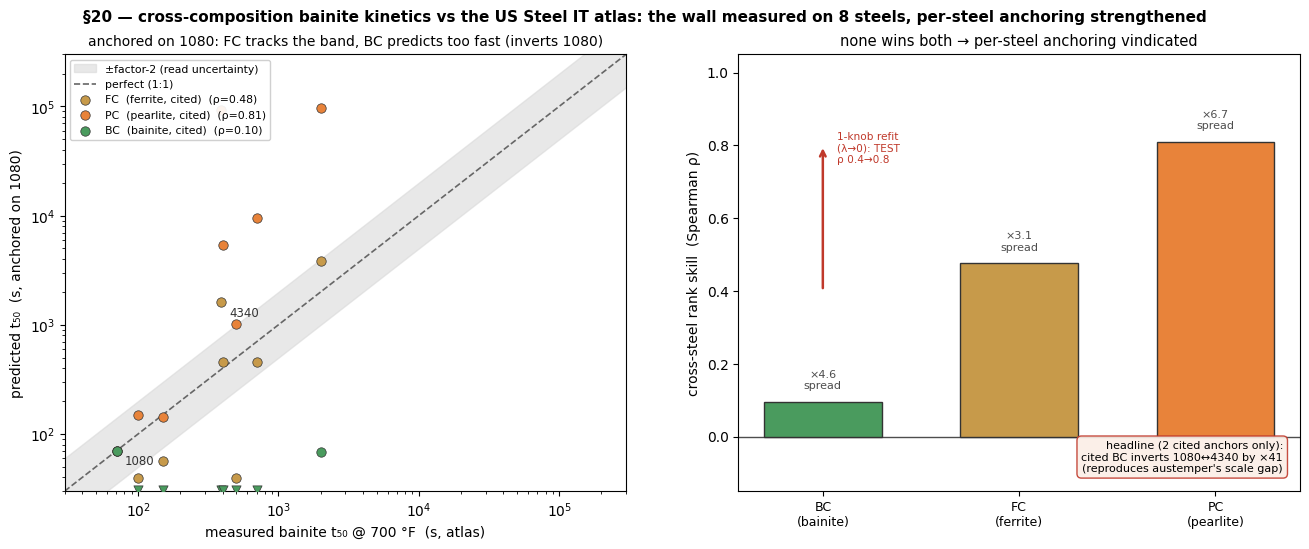

bias-immune headline (two cited anchors only): atlas measures 4340 x6 SLOWER than 1080;
   cited BC predicts x7 FASTER -> ratio missed x41, sign-inverted = True
   PC (cited)  rank rho +0.81   mag spread x6.7   inverts 1080: False
   FC (cited)  rank rho +0.48   mag spread x3.1   inverts 1080: False
   BC (cited)  rank rho +0.10   mag spread x4.6   inverts 1080: True
none combines order + magnitude -> no cross-steel bainite law in these factors -> per-steel anchoring (§6/§6b) VINDICATED. Isothermal atlas (not a measured-CCT benchmark); no engine touch.


In [ ]:
from steel.demo_cct_validation import compute as cct_compute
from steel.plots import cct_validation_figure

d = cct_compute()                                   # 8-steel grading vs the IT atlas (banked static)
cct_validation_figure(d)
plt.show()

w = d.wall
print(f"bias-immune headline (two cited anchors only): atlas measures 4340 x{w.measured_ratio:.0f} SLOWER "
      f"than 1080;")
print(f"   cited BC predicts x{1/w.bc_ratio:.0f} FASTER -> ratio missed x{w.miss:.0f}, sign-inverted = {w.sign_inverted}")
label = {"pearlite": "PC", "ferrite": "FC", "bainite": "BC"}
for which in ("pearlite", "ferrite", "bainite"):
    g = d.grades[which]
    print(f"   {label[which]} (cited)  rank rho {g.spearman:+.2f}   mag spread x{10**g.log_resid_spread:.1f}"
          f"   inverts 1080: {g.inverts_1080}")
print("none combines order + magnitude -> no cross-steel bainite law in these factors -> "
      "per-steel anchoring (§6/§6b) VINDICATED. Isothermal atlas (not a measured-CCT benchmark); no engine touch.")

## 6d · Martempering — the same hardness, far less distortion (Phase 6e)

Austempering (§6) holds *long* inside the diagram to grow bainite. **Martempering** holds *briefly* just **above** Mₛ — only long enough to **equalise** the section, well under the bainite clock — then slow-cools through Mₛ near-uniformly. The microstructure and hardness come out matching a **direct quench point-for-point** (exact by construction — it is *not* a claim that a shallow steel through-hardens a thick part); what changes is the *spatial* picture at the moment martensite forms.

A direct quench takes the surface through Mₛ while the centre is still tens of degrees hotter, and that through-section gradient is what warps and cracks parts. Martempering closes the gap *before* transformation, cutting the surface−centre ΔT at Mₛ by a large factor (here ~60× for a 1080 plate). The catch is **feasibility**: the section must equalise before bainite nucleates (`τ_eq < t_crit`), which thin / hardenable sections clear and thick ones do not — 4340's 40 mm plate fails, the textbook section-size limit, reproduced. Banked artifact: [`demo_martemper`](demo_martemper.py); drag the steel and thickness yourself in the Streamlit app (`app.py`).

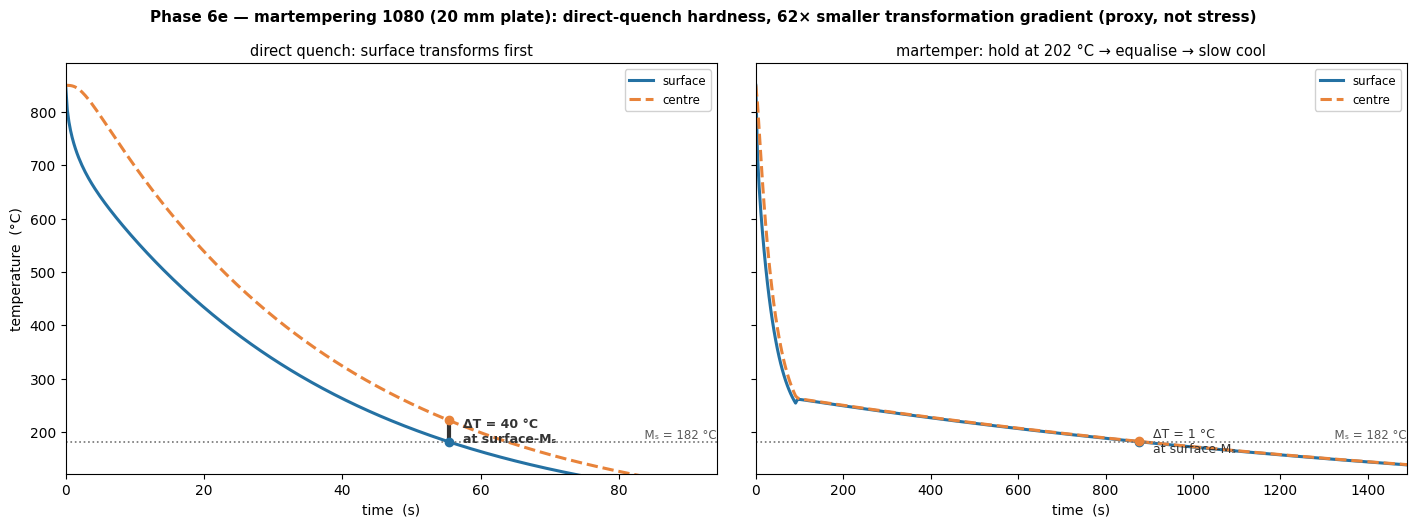

equivalence (martemper HV = ideal nose-missing quench HV, exact by construction):
   1080: martemper  732 HV  ==  direct quench  732 HV
   4340: martemper  643 HV  ==  direct quench  643 HV
distortion (1080, 20 mm plate): surface-centre dT at Ms 40 -> 1 C  = x62 smaller
feasibility (tau_eq < t_crit -- equalise before bainite?):
   1080    10 mm  ->  feasible


   1080    40 mm  ->  feasible
   4340    10 mm  ->  feasible


   4340    40 mm  ->  INFEASIBLE (bainite first)
4340's 40 mm plate fails -- the textbook limit. No new physics; built on §6's anchored kinetics.


In [ ]:
from steel.demo_martemper import compute as mt_compute
from steel import martemper as _mt
from steel.plots import martemper_distortion_figure

dc = mt_compute()                                   # 1080, 20 mm plate: direct vs martemper (banked static)
martemper_distortion_figure(dc)
plt.show()

print("equivalence (martemper HV = ideal nose-missing quench HV, exact by construction):")
for s in ("1080", "4340"):
    iq = _mt.ideal_quench(s); r = _mt.martemper(s, T_bath=iq.Ms + 20.0, t_hold=30.0)
    print(f"   {s}: martemper {r.HV:4.0f} HV  ==  direct quench {r.quench_HV:4.0f} HV")
print(f"distortion ({dc.steel}, {2000*dc.half_thickness:.0f} mm plate): surface-centre dT at Ms "
      f"{abs(dc.gradient_direct):.0f} -> {abs(dc.gradient_martemper):.0f} C  = x{dc.reduction:.0f} smaller")
print("feasibility (tau_eq < t_crit -- equalise before bainite?):")
for s, L in (("1080", 0.005), ("1080", 0.020), ("4340", 0.005), ("4340", 0.020)):
    f = _mt.feasibility(s, L)
    print(f"   {s}  {2000*L:4.0f} mm  ->  {'feasible' if f.feasible else 'INFEASIBLE (bainite first)'}")
print("4340's 40 mm plate fails -- the textbook limit. No new physics; built on §6's anchored kinetics.")

## 6e · Residual stress on quench — why a through-hardened part can crack (§18)

§6d showed martempering shrinks the *thermal* gradient. This section asks what **stress** a quench leaves behind — the first piece of the simulator to model **solid mechanics**. A plate quenched while it transforms locks in a self-balancing residual-stress field, read once it has cooled to room temperature.

The headline is a **sign reversal**. With transformation *off* (thermal contraction only) the hot core yields and pulls the surface into **compression** — benign, even beneficial. Turn transformation *on*: the austenite→martensite **dilatation** makes the surface, which transforms and hardens first, get stretched by the late-expanding core, flipping it to **tension** — the quench-crack-prone state. **Martempering removes** that surface tension — §6d's distortion benefit, now quantitative in stress. The model is incremental **elastic–perfectly-plastic** with a temperature-dependent yield (cited Eurocode-3 `E(T)` / `σ_Y(T)`), and the stress integrates to zero across the section to machine precision (conservation, not a fit). The **teeth are the signs**, the equilibrium, and the route ratio — not the absolute MPa (no transformation plasticity / TRIP; through-hardening only). Banked artifact: [`demo_residual`](demo_residual.py); the live section-size / quench knobs are in the app (`app.py`).

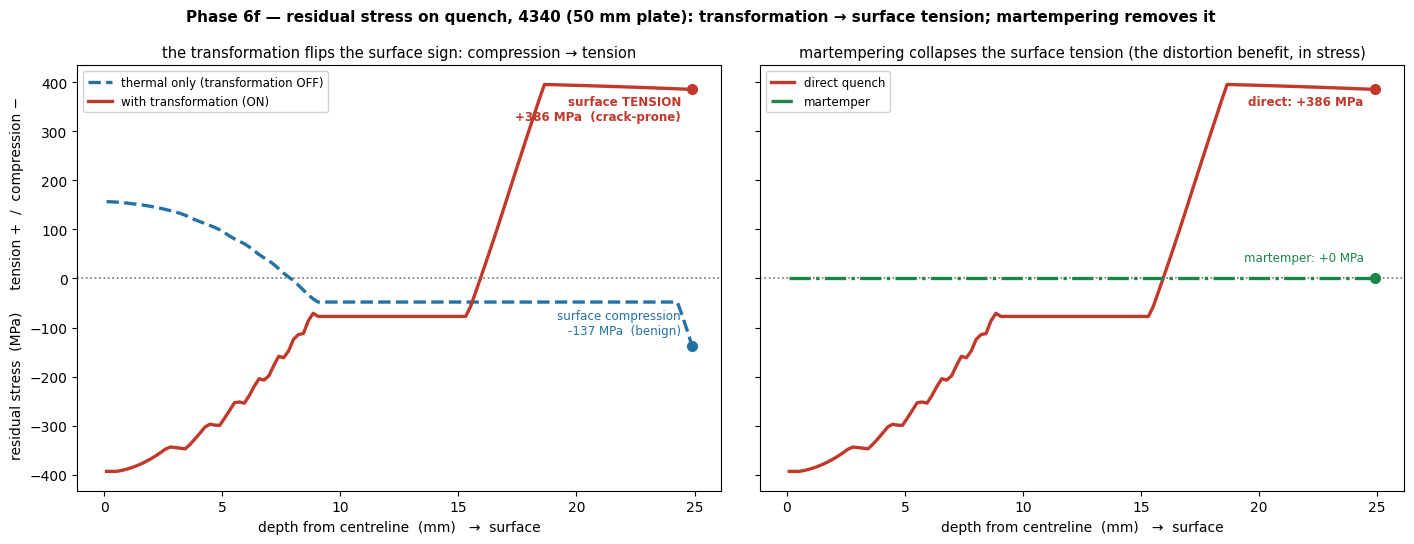

surface stress (4340, 50 mm water quench, Ms 294 C):
   thermal only (transform OFF):   -137 MPa  -> compression -- benign
   with transform   (ON)       :   +386 MPa  -> TENSION -- quench-crack-prone
   martemper                   :     +0 MPa  -> surface tension removed
self-equilibrium: integral(sigma) ~ mean = 2.2e-07 Pa (about 0, machine precision); peak |sigma| ~ 396 MPa
teeth = the signs / equilibrium / route ratio, not the MPa. No TRIP; through-hardening only. The first solid mechanics in the project.


In [ ]:
from steel.demo_residual import compute as res_compute
from steel.plots import residual_stress_figure

on, off, marte = res_compute(n_t=2500)              # 4340, 50 mm water: OFF / ON / martemper (banked static)
residual_stress_figure(on, off, marte)
plt.show()

print(f"surface stress ({on.steel}, {2000*on.half_thickness:.0f} mm water quench, Ms {on.Ms:.0f} C):")
print(f"   thermal only (transform OFF): {off.surface_MPa:+6.0f} MPa  -> "
      f"{'compression -- benign' if off.surface_stress < 0 else 'tension'}")
print(f"   with transform   (ON)       : {on.surface_MPa:+6.0f} MPa  -> "
      f"{'TENSION -- quench-crack-prone' if on.surface_stress > 0 else 'compression'}")
print(f"   martemper                   : {marte.surface_MPa:+6.0f} MPa  -> surface tension removed")
peak = max(abs(on.peak_tension), abs(on.peak_compression)) / 1e6
print(f"self-equilibrium: integral(sigma) ~ mean = {on.mean_stress:.1e} Pa (about 0, machine precision); "
      f"peak |sigma| ~ {peak:.0f} MPa")
print("teeth = the signs / equilibrium / route ratio, not the MPa. No TRIP; through-hardening only. "
      "The first solid mechanics in the project.")

## 7 · Inverse design: name a hardness, get the recipe (Phase 7)

Sections 1–6 all run the model **forwards** — pick a steel and a heat treatment, read off the
hardness. This one runs it **backwards**. Name a **target hardness** and a **section size**, and
it searches every grade × quench × temper for the recipes that hit it, then names the cheapest —
the engineer's actual question (*what steel and heat treatment gives me 45 HRC at this size?*).

It adds **no physics**: it just *inverts* the validated forward chain the sections above built, so
a recipe is reported only if re-running the forward model lands it back in your band. The temper
step is found exactly (the tempered-hardness curve is monotone, so a quick **root-find** inverts
it); an impossible target honestly returns **nothing** — not a near miss. The hardness is the
**bulk** value of a section of that size (section size enters through cooling rate), *not* a
radial profile — that is the Jominy / critical-diameter view. The cost ranking is a transparent
convenience (leaner alloy + milder quench + no extra temper step ⇒ lower), **not** a validated
cost model.

> The banked artifact is [`demo_design`](demo_design.py); the harness is [`design`](design.py)
> (its tests are *harness correctness*, like `sweep` — this section invents no new physics).

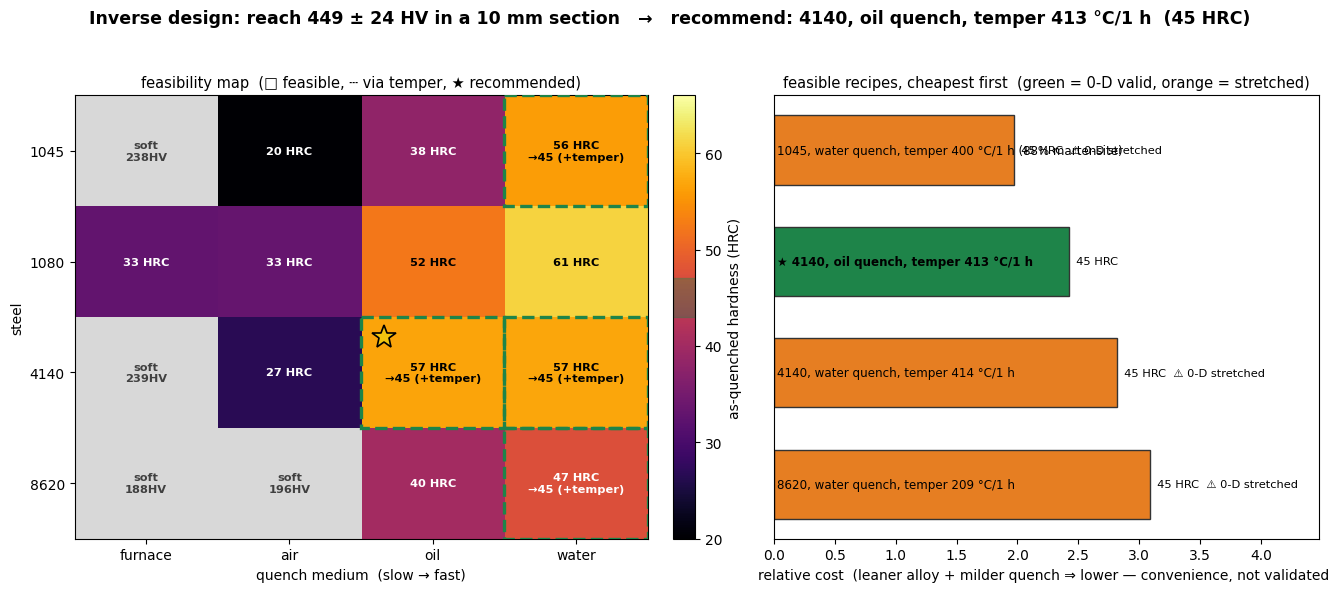

target 45 ± 2 HRC (424–473 HV) in a 10 mm section
   recommended (cheapest 0-D-valid): 4140, oil quench, temper 413 °C/1 h  ->  449 HV ≈ 45 HRC  · 0-D model valid
   also feasible: 1045, water quench, temper 400 °C/1 h (88% martensite)  ->  45 HRC  ⚠ 0-D stretched
   also feasible: 4140, water quench, temper 414 °C/1 h  ->  45 HRC  ⚠ 0-D stretched
   also feasible: 8620, water quench, temper 209 °C/1 h  ->  45 HRC  ⚠ 0-D stretched


In [19]:
from steel import design
from steel.plots import design_figure

def design_explorer(target_hrc=45.0, tol_hrc=2.0, section_mm=10.0):
    # Hardness spec + section size -> the feasible recipe set: outer grade x quench enumeration
    # + an inner temper root-find (design.find_recipes_for_HRC), every recipe re-checked against
    # the band. The as-quenched landscape grid feeds the same figure (the render layer owns it).
    d_m = float(section_mm) / 1000.0
    result = design.find_recipes_for_HRC(float(target_hrc), tol_HRC=float(tol_hrc), diameter=d_m)
    grid = sweep.sweep_grid(GRADES, media=DEFAULT_MEDIA, diameter=d_m)
    design_figure(result, grid)
    plt.show()                                   # figure FIRST, then the readout (flicker-safe)
    lo, hi = result.target_band
    print(f"target {target_hrc:.0f} ± {tol_hrc:.0f} HRC ({lo:.0f}–{hi:.0f} HV) "
          f"in a {section_mm:.0f} mm section")
    if not result.feasible:
        print("   no recipe in this grade × quench × temper space reaches it "
              "— the target is outside the achievable envelope.")
        return
    def _hrc(r):
        return f"{r.HRC:.0f} HRC" if np.isfinite(r.HRC) else "(off HRC scale)"
    rec = result.recommended
    valid = "0-D model valid" if rec.lumped_valid else "⚠ 0-D lumped model stretched (Biot > 0.1)"
    print(f"   recommended (cheapest 0-D-valid): {rec.label()}  ->  {rec.HV:.0f} HV ≈ {_hrc(rec)}  · {valid}")
    for r in result.recipes:
        if r is rec:                                 # the recommended is printed above
            continue
        flag = "" if r.lumped_valid else "  ⚠ 0-D stretched"
        print(f"   also feasible: {r.label()}  ->  {_hrc(r)}{flag}")

# Direct render (static, banked in the .ipynb) — the textbook quench-and-temper spec:
# ~45 HRC in a 10 mm section -> 4140, oil quench, temper ~425 °C (the classic Q&T answer).
design_explorer(45.0, 2.0, 10.0)

In [20]:
# target 25-60 HRC (± up to 4) keeps the spec inside the ASTM E140 convertible band; section
# 5-60 mm spans thin (through-hardens) to thick (only the deep-hardening alloy survives).
interact(
    design_explorer,
    target_hrc=widgets.IntSlider(value=45, min=25, max=60, step=1, description="target HRC",
                                 continuous_update=False, style={"handle_color": KNOB}),
    tol_hrc=widgets.IntSlider(value=2, min=1, max=4, step=1, description="± HRC",
                              continuous_update=False, style={"handle_color": KNOB}),
    section_mm=widgets.IntSlider(value=10, min=5, max=60, step=5, description="section mm",
                                 continuous_update=False, style={"handle_color": KNOB}),
);

interactive(children=(IntSlider(value=45, continuous_update=False, description='target HRC', max=60, min=25, s…

## 8 · Carburizing — a hard case over a tough core (Phase 3c)

A coda on a different process. Everything above hardens by **cooling rate**; case hardening works by **composition**. The same frozen diffusion engine that cooled the Jominy bar in *heat* mode now runs in *mass* mode — diffusing carbon **into** the surface of a low-carbon (≈8620, 0.2 %C) gear held in a carburizing atmosphere, then quenching the whole part once.

The result is a hardness gradient set by the **carbon** gradient (not a cooling gradient — one quench throughout): a hard ~60–65 HRC martensite **case** over a softer, tougher **core** — exactly what a gear tooth wants (a wear-resistant skin over a shock-absorbing interior). Surface hardness is read off the martensite **potential** (the case as designed); the retained austenite a heavy case really carries is reported honestly, not asserted. Case depth scales as √(D·t) — the classic carburizing knob. Banked artifact: [`demo_carburize`](demo_carburize.py); the live atmosphere / time / temperature knobs are in the app (`app.py`).

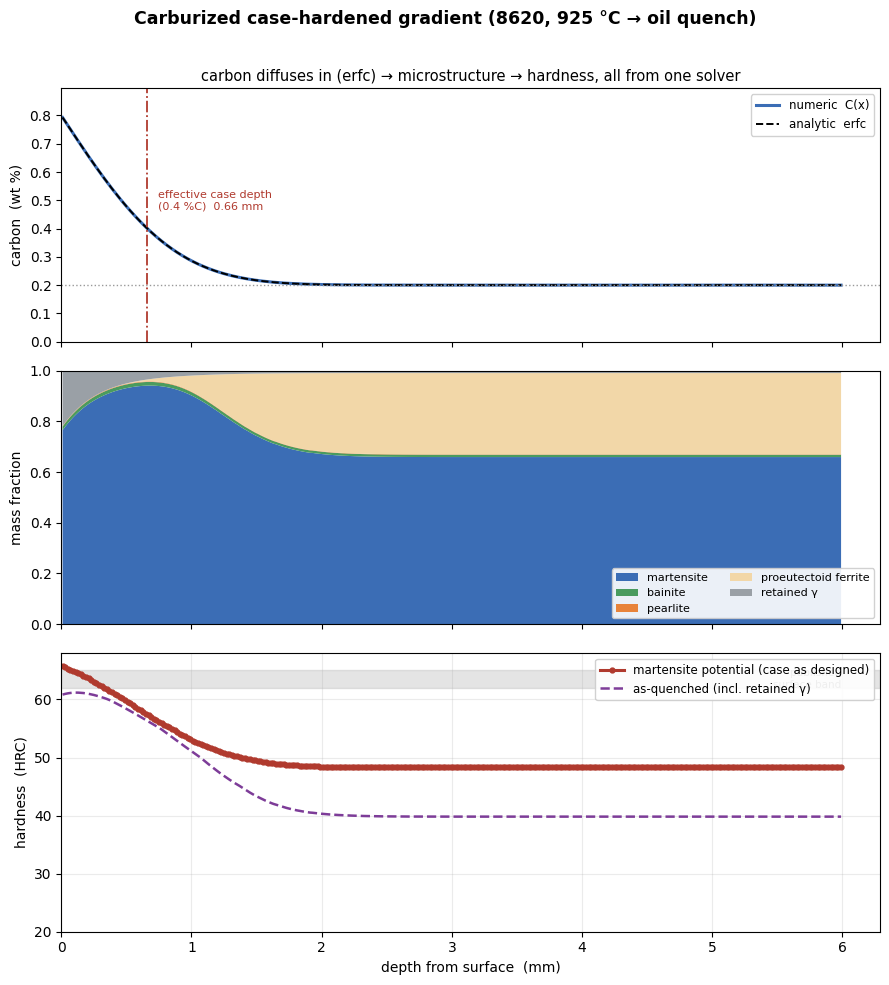

carburized 925 C, surface 0.8 %C over 0.2 %C core (D = 8.12e-12 m2/s):
   case depth: 0.66 mm to 0.4 %C   |   1.39 mm to 50 HRC
   surface 66 HRC (857 HV potential) hard martensite case  -> core 48 HRC softer/tougher
   surface retained austenite 22% (the real heavy-case effect, reported)
hardness set by the CARBON gradient, one quench throughout. Same sealed engine as Jominy, mass-mode face.


In [ ]:
from steel.demo_carburize import compute as cb_compute
from steel.plots import carburize_figure

profile, traverse = cb_compute()                    # 925 C, 8 h, 0.8 %C, oil quench (banked static)
carburize_figure(profile, traverse)
plt.show()

print(f"carburized {profile.T_carburize:.0f} C, surface {profile.C_surface:.1f} %C over "
      f"{profile.C_core:.1f} %C core (D = {profile.D:.2e} m2/s):")
print(f"   case depth: {profile.case_depth(0.4)*1000:.2f} mm to 0.4 %C   |   "
      f"{traverse.case_depth_50HRC()*1000:.2f} mm to 50 HRC")
print(f"   surface {traverse.HRC[0]:.0f} HRC ({traverse.HV[0]:.0f} HV potential) hard martensite case  "
      f"-> core {traverse.HRC[-1]:.0f} HRC softer/tougher")
print(f"   surface retained austenite {traverse.retained_austenite[0]*100:.0f}% (the real heavy-case effect, reported)")
print("hardness set by the CARBON gradient, one quench throughout. Same sealed engine as Jominy, mass-mode face.")

## Where the numbers come from

Nothing above is computed *here*. Each slider re-runs a headless harness —
[`sweep`](sweep.py) (itself **pure re-composition** of the validated chain
`ccurve_for_steel → cooling → pathint → properties`) for §1–§4,
[`grain`](grain.py) (`coupled_grain_properties`: PAGS → ferrite → yield + DBTT)
for §5, and [`austemper`](austemper.py) (the atlas-anchored isothermal bainite hold)
for §6 — and every constituent hardness, kinetic constant, tempering breakpoint,
and grain-growth coefficient is anchored and tested in its own module. The
shareable Streamlit twin of this surface is **slice 2** (`app.py`); the headless
artifacts behind it are [`demo_sweep`](demo_sweep.py), [`demo_grain`](demo_grain.py)
and [`demo_austemper`](demo_austemper.py). The newer **static** views — the critical-diameter cross-check (§3), the measured cross-composition wall (§6c), martempering (§6d), **residual stress** (§6e, the project's first *solid mechanics*) and carburizing (§8) — each bank a figure from the same validated demos ([`demo_ideal_diameter`](demo_ideal_diameter.py), [`demo_cct_validation`](demo_cct_validation.py), [`demo_martemper`](demo_martemper.py), [`demo_residual`](demo_residual.py), [`demo_carburize`](demo_carburize.py)) and carry their own named scope edges inline; their live knobs are in the app.

> **Scope, stated honestly.** The cooling histories are 0-D lumped-capacitance
> (the Biot flag fires when that's stretched); hardness is compared in **HV**
> (defined everywhere; HRC is `nan` below ~20 HRC); tempering is
> **martensite-only**. §5's grain laws are the **normalized / slow-cooled**
> ferrite-pearlite regime (not the quenched martensite of §1–§4), and their
> co-benefit / over-austenitizing *directions* hold **by construction** from the
> two cited Pickering signs — a demonstration, with Phase 5's falsifiable teeth in
> 5a's grain-growth holdout. §6's austempering claims stop at the atlas **50 % line**, per-steel
> anchored (no cross-composition prediction — probe-falsified). These are the same
> edges the harness docstrings carry — surfaced, not hidden.